<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo5tts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# 감지된 이미지 관련 음성으로 들려주기
# TTS (Text To Speech) ↔ STT (Speech To Text)

# 유기동물 탐지 후 보호소 안내 메세지 음성으로 출력

!pip install ultralytics opencv-python playsound==1.2.2 gtts

In [22]:
# TTS 연습
from gtts import gTTS
from IPython.display import Audio     # jupyter notebook 용
from playsound import playsound       # local 편집기용(vsc, ...)

def speakFunc(message):
  tts = gTTS(text=message, lang='ko')
  tts.save('yolo5test.mp3')   # 음성 파일로 저장
  return Audio('yolo5test.mp3', autoplay=True)  # 재생 (Jupyter)
  playsound('yolo5test.mp3')   # 재생 (local)

message = "제로슈거 제품도 안심할 수 없다. 조영규 센터장은 “제로콜라처럼 당류가 없거나 낮췄다고 홍보하는 가공식품은 포화지방 등 다른 영양 성분이 높을 가능성이 있다”며 “저당이라는 이름으로 과식해도 해가 되지 않을 것이라는 면죄부를 줘 오히려 건강에 악영향을 줄 수 있다”고 말했다."
speakFunc(message)

In [23]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio     # jupyter notebook 용
from playsound import playsound       # local 편집기용(vsc, ...)
from datetime import datetime

# 보호소 정보 안내 (텍스트 + 음성 재생)
def show_shelter_info_func(region, shelters, detected_info):
  shelter_info = shelters.get(region, shelters['전국'])   # shelters에 서울 없으면 전국이 기본값
  pet_summary = f"{detected_info['count']}마리 ({', '.join(detected_info['labels'])})"

  message = (
      f"유기 동물 탐지 결과:\n"
      f"- 탐지된 동물 수:{detected_info['count']}\n"
      f"- 종류:{detected_info['labels']}\n"
      f"{region} 보호소 정보:\n{shelter_info}"
  )
  print('보호소 정보 :', message)

  # 음성 안내
  try:
    tts = gTTS(text=f"{region} 지역에 유기된 {pet_summary}가 감지되었습니다. 가까운 보호소는 {shelter_info}입니다.", lang='ko')
    tts.save('yolo5shelter.mp3')
    display(Audio('yolo5shelter.mp3', autoplay=True))
    # playsound('yolo5shelter.mp3')

  except Exception as e:
    print(f'음성안내 실패 : {e}')

def handle_stray_pet_func(region, shelters, detected_info):
  print('유기 동물로 추정됨')
  show_shelter_info_func(region, shelters, detected_info)

region = "테헤란로 사거리 삼원빌딩 앞"
shelters = {
    '서울':'서울 반려동물 보호센터:02-1234-5678',
    '전국':'전국 유기동물 보호연합:1577-8888'
}
detected_info = {
    'count':3,
    'labels':['호랑이', '사자', '코끼리']
}

handle_stray_pet_func(region, shelters, detected_info)

유기 동물로 추정됨
보호소 정보 : 유기 동물 탐지 결과:
- 탐지된 동물 수:3
- 종류:['호랑이', '사자', '코끼리']
테헤란로 사거리 삼원빌딩 앞 보호소 정보:
전국 유기동물 보호연합:1577-8888



0: 640x608 1 cat, 1 dog, 1875.1ms
Speed: 8.2ms preprocess, 1875.1ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 608)
결과 이미지 저장 완료


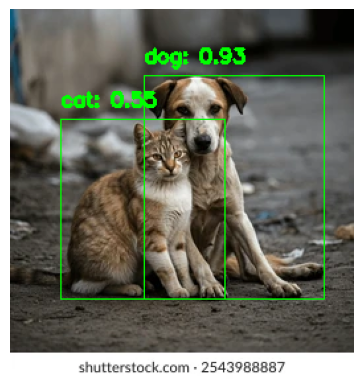


유기 동물 탐지 결과
 - 댕댕이
 - 냥이
탐지 결과가 yolo5log.txt로 저장됨
유기 동물로 추정됨
보호소 정보 : 유기 동물 탐지 결과:
- 탐지된 동물 수:2
- 종류:['냥이', '댕댕이']
인천 보호소 정보:
전국 유기동물 보호연합:1577-8888


In [25]:
# 본격적으로 이미지내 객체 감지 후 함수 호출

# 탐지 정보 로그 저장
def save_detection_log_func(image_path, detection_data):
  log_file = 'yolo5log.txt'
  now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
  with open(log_file, 'a', encoding='utf-8') as f:
    f.write(f'\n{now} 이미지:{image_path}\n')
    f.write(f'탐지된 객체 수 : {len(detection_data)}\n')
    for d in detection_data:
      f.write(f' - {d['label']}: box={d['box']}, confidence={d['confidence']:.2f}\n')
    f.write('-' * 40 + '\n')
    print(f'탐지 결과가 {log_file}로 저장됨')

# 유기동물 감지 함수
def detect_pets_func(image_path):
  pet_desc = {
      'dog':'댕댕이',
      'cat':'냥이',
  }
  shelters = {
      '서울':'서울 반려동물 보호센터:02-1234-5678',
      '부산':'부산 유기동물 보호소:051-1234-1324',
      '전국':'전국 유기동물 보호연합:1577-8888'
  }

  stray_keywords = ['street', 'road', 'outside', 'stray']

  model = YOLO('yolo11m.pt')

  image = cv2.imread(image_path)
  if image is None:
    print('이미지를 부를 수 없어요')
    return

  results = model(image, conf=0.5)
  detected_pets = []    # 감지된 객체 레이블 저장
  detection_data = []   # 감지된 객체 정보 저장

  for result in results:
    for box in result.boxes:
      x1, y1, x2, y2 = map(int, box.xyxy[0])
      label = result.names[int(box.cls[0])]
      confidence = box.conf[0].item()

      if label in pet_desc:
        detected_pets.append(label)
        detection_data.append({
            'label':pet_desc[label],
            'box':(x1, y1, x2, y2),
            'confidence':confidence
        })
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 1)
        cv2.putText(image, f'{label}: {confidence:.2f}', (x1, y1 -10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

  # 결과 이미지 저장
  output_path = 'yolo5out.jpg'
  cv2.imwrite(output_path, image)
  print('결과 이미지 저장 완료')
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

  if detected_pets:
    print("\n유기 동물 탐지 결과")
    for pet in detected_pets:
      print(f' - {pet_desc.get(pet, pet)}')

  # 감지정보 파일로 저장
  save_detection_log_func(image_path, detection_data)

  # 유기동물 조건 확인
  # 감지 동물이 dog, cat이고 이미지 경로에 'street', 'stray' 등의 키워드가 포함되면 유기동무로 판단
  if any(pet in ['dog', 'cat'] for pet in detected_pets) and \
     any(keyword in image_path.lower() for keyword in stray_keywords):
    detected_info = {
        'count':len(detection_data),
        'labels':sorted(set([d['label'] for d in detection_data]))
    }

    # 유기 동물로 판단되었으므로 보호소 정보를 음성 + 텍스트로 안내
    handle_stray_pet_func(region="인천", shelters=shelters, detected_info=detected_info)
  else:
    print('유기 동물로 추정되지 않음')


detect_pets_func('street_ani.jpg')